# Token Distribution Analysis: GSM8K + CompMath

This notebook analyzes the reasoning token distributions across low/medium/high modes for merged GSM8K and CompMath datasets.

In [3]:
!pip install seaborn

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List, Dict

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

## 1. Load Data

In [4]:
def read_jsonl(file_path: Path) -> List[Dict]:
    """Read JSONL file and return list of records."""
    records = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return records

def extract_mode(filename: str) -> str:
    """Extract mode from filename."""
    filename_lower = filename.lower()
    if 'low' in filename_lower:
        return 'low'
    elif 'med' in filename_lower:
        return 'medium'
    elif 'high' in filename_lower:
        return 'high'
    return 'unknown'

# Define data directory
data_dir = Path('./new_dataset/0_raw')

# Load all data
all_data = []

for dataset in ['gsm8k', 'compmath']:
    dataset_dir = data_dir / dataset
    
    if not dataset_dir.exists():
        print(f"Warning: {dataset_dir} not found")
        continue
    
    for file_path in sorted(dataset_dir.glob('*.jsonl')):
        mode = extract_mode(file_path.name)
        records = read_jsonl(file_path)
        
        # Add metadata
        for record in records:
            record['dataset'] = dataset
            record['mode'] = mode
            record['file'] = file_path.name
        
        all_data.extend(records)
        print(f"Loaded {len(records):6d} samples from {file_path.name}")

print(f"\nTotal samples loaded: {len(all_data)}")

Loaded  25250 samples from gsm8k_train_high.jsonl
Loaded  32266 samples from gsm8k_train_low.jsonl
Loaded  27661 samples from gsm8k_train_med.jsonl
Loaded  14945 samples from compmath_train_high.jsonl
Loaded  16524 samples from compmath_train_low.jsonl
Loaded  16003 samples from compmath_train_med.jsonl

Total samples loaded: 132649


In [2]:
def read_jsonl(file_path: Path) -> List[Dict]:
    """Read JSONL file and return list of records."""
    records = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return records

def extract_mode(filename: str) -> str:
    """Extract mode from filename."""
    filename_lower = filename.lower()
    if 'low' in filename_lower:
        return 'low'
    elif 'med' in filename_lower:
        return 'medium'
    elif 'high' in filename_lower:
        return 'high'
    return 'unknown'

# Define data directory
data_dir = Path('/home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/0_raw')

# Load all data
all_data = []

for dataset in ['gsm8k', 'compmath']:
    dataset_dir = data_dir / dataset
    
    if not dataset_dir.exists():
        print(f"Warning: {dataset_dir} not found")
        continue
    
    for file_path in sorted(dataset_dir.glob('*.jsonl')):
        mode = extract_mode(file_path.name)
        records = read_jsonl(file_path)
        
        # Add metadata
        for record in records:
            record['dataset'] = dataset
            record['mode'] = mode
            record['file'] = file_path.name
        
        all_data.extend(records)
        print(f"Loaded {len(records):6d} samples from {file_path.name}")

print(f"\nTotal samples loaded: {len(all_data)}")

Loaded  25250 samples from gsm8k_train_high.jsonl
Loaded  32266 samples from gsm8k_train_low.jsonl
Loaded  27661 samples from gsm8k_train_med.jsonl
Loaded  14945 samples from compmath_train_high.jsonl
Loaded  16524 samples from compmath_train_low.jsonl
Loaded  16003 samples from compmath_train_med.jsonl

Total samples loaded: 132649


## 2. Create DataFrame

In [3]:
from transformers import AutoTokenizer
import pandas as pd

# Load GPT-OSS tokenizer
tokenizer = AutoTokenizer.from_pretrained("/mnt/dataset1/pretrained_fm/gpt-oss-20b")

def count_tokens(text):
    if text is None:
        return 0
    return len(tokenizer.encode(text, add_special_tokens=False))

df = pd.DataFrame([
    {
        'dataset': record.get('dataset'),
        'mode': record.get('mode'),
        'file': record.get('file'),

        # Choose what you want to count:
        # "response", "reasoning", "output", etc.
        'reasoning_tokens': count_tokens(record.get('response', ''))
    }
    for record in all_data
])

print("DataFrame shape:", df.shape)
df.head(20)


/opt/miniconda3/envs/khoina_oss/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DataFrame shape: (132649, 4)


,dataset,mode,file,reasoning_tokens
0,gsm8k,high,gsm8k_train_high.jsonl,80
1,gsm8k,high,gsm8k_train_high.jsonl,478
2,gsm8k,high,gsm8k_train_high.jsonl,128
3,gsm8k,high,gsm8k_train_high.jsonl,277
4,gsm8k,high,gsm8k_train_high.jsonl,287
5,gsm8k,high,gsm8k_train_high.jsonl,103
6,gsm8k,high,gsm8k_train_high.jsonl,163
7,gsm8k,high,gsm8k_train_high.jsonl,251
8,gsm8k,high,gsm8k_train_high.jsonl,211
9,gsm8k,high,gsm8k_train_high.jsonl,526


In [4]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Remove rows with 0 or negative reasoning tokens
df = df[df['reasoning_tokens'] > 0]
print(f"\nAfter filtering: {len(df)} samples")

Missing values:
dataset             0
mode                0
file                0
reasoning_tokens    0
dtype: int64

After filtering: 221582 samples


## 3. Summary Statistics

In [5]:
# Overall statistics
print("="*80)
print("OVERALL STATISTICS")
print("="*80)

overall_stats = df['reasoning_tokens'].describe()
print(overall_stats)
print(f"\nStandard Deviation: {df['reasoning_tokens'].std():.2f}")

OVERALL STATISTICS
count    221582.000000
mean        563.345773
std         646.411367
min          11.000000
25%         108.000000
50%         264.000000
75%         744.000000
max        2061.000000
Name: reasoning_tokens, dtype: float64

Standard Deviation: 646.41


## 4. Statistics by Mode

In [4]:
# Group by mode
mode_stats = df.groupby('mode')['reasoning_tokens'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('std', 'std'),
    ('median', 'median'),
    ('min', 'min'),
    ('max', 'max'),
    ('q25', lambda x: x.quantile(0.25)),
    ('q75', lambda x: x.quantile(0.75)),
]).round(2)

# Add formatted columns
mode_stats['mean ± std'] = mode_stats.apply(
    lambda row: f"{row['mean']:.2f} ± {row['std']:.2f}", axis=1
)

mode_stats['q25–q75'] = mode_stats.apply(
    lambda row: f"{row['q25']:.2f} – {row['q75']:.2f}", axis=1
)

print("\n" + "="*80)
print("STATISTICS BY MODE (Combined GSM8K + CompMath)")
print("="*80)
print(mode_stats.to_string())

# Save to CSV
mode_stats.to_csv('token_stats_by_mode.csv')
print("\nSaved to: token_stats_by_mode.csv")


STATISTICS BY MODE (Combined GSM8K + CompMath)
        count    mean     std  median  min   max    q25    q75       mean ± std          q25–q75
mode                                                                                            
high    40195  337.67  174.24   307.0   40  1190  200.0  451.0  337.67 ± 174.24  200.00 – 451.00
low     48790   72.88   34.75    64.0    0   262   47.0   91.0    72.88 ± 34.75    47.00 – 91.00
medium  43664  176.22   89.53   155.0   34   652  106.0  229.0   176.22 ± 89.53  106.00 – 229.00

Saved to: token_stats_by_mode.csv


## 5. Statistics by Dataset

In [5]:
# Group by dataset
dataset_stats = df.groupby('dataset')['reasoning_tokens'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('std', 'std'),
    ('median', 'median'),
    ('min', 'min'),
    ('max', 'max'),
]).round(2)

dataset_stats['mean ± std'] = dataset_stats.apply(
    lambda row: f"{row['mean']:.2f} ± {row['std']:.2f}", axis=1
)

print("\n" + "="*80)
print("STATISTICS BY DATASET")
print("="*80)
print(dataset_stats.to_string())


STATISTICS BY DATASET
          count    mean     std  median  min   max       mean ± std
dataset                                                            
compmath  47472  231.47  182.07   171.0   13  1190  231.47 ± 182.07
gsm8k     85177  162.42  131.06   114.0    0   810  162.42 ± 131.06


## 6. Statistics by Dataset AND Mode

In [6]:
# Group by both dataset and mode
dataset_mode_stats = df.groupby(['dataset', 'mode'])['reasoning_tokens'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('std', 'std'),
    ('median', 'median'),
    ('q25', lambda x: x.quantile(0.25)),
    ('q75', lambda x: x.quantile(0.75)),
    ('min', 'min'),
    ('max', 'max'),
]).round(2)

# Add formatted mean ± std column
dataset_mode_stats['mean ± std'] = dataset_mode_stats.apply(
    lambda row: f"{row['mean']:.2f} ± {row['std']:.2f}", axis=1
)

print("\n" + "=" * 80)
print("STATISTICS BY DATASET AND MODE (WITH Q25 / Q75)")
print("=" * 80)
print(dataset_mode_stats.to_string())

# Save to CSV
dataset_mode_stats.to_csv('token_stats_by_dataset_mode.csv')
print("\nSaved to: token_stats_by_dataset_mode.csv")


STATISTICS BY DATASET AND MODE (WITH Q25 / Q75)
                 count    mean     std  median    q25    q75  min   max       mean ± std
dataset  mode                                                                           
compmath high    14945  401.28  200.90   372.0  237.0  534.0   40  1190  401.28 ± 200.90
         low     16524   90.73   43.20    83.0   56.0  121.0   13   262    90.73 ± 43.20
         medium  16003  218.19  105.65   200.0  133.0  292.0   35   652  218.19 ± 105.65
gsm8k    high    25250  300.02  143.62   275.0  183.0  405.0   47   810  300.02 ± 143.62
         low     32266   63.73   24.96    59.0   45.0   78.0    0   201    63.73 ± 24.96
         medium  27661  151.94   67.73   139.0   98.0  194.0   34   479   151.94 ± 67.73

Saved to: token_stats_by_dataset_mode.csv


## 7. Distribution Plots

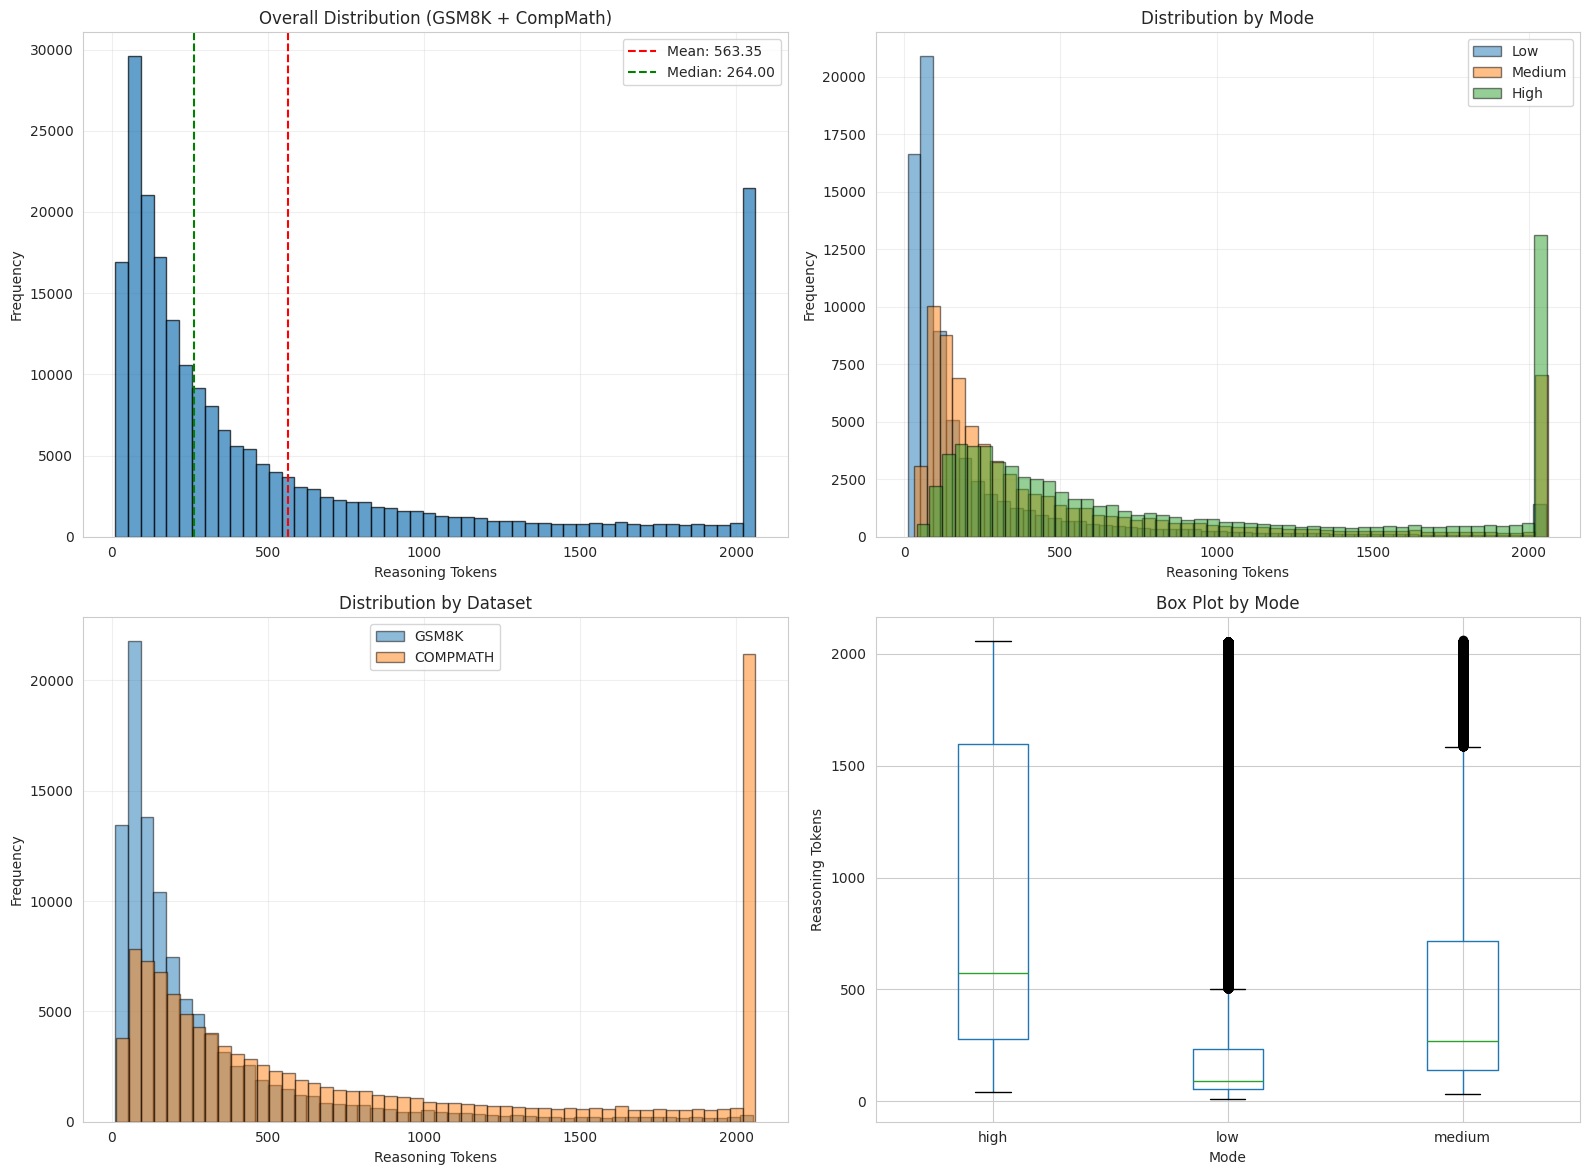


Saved plot to: token_distribution_analysis.png


In [9]:
# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Overall distribution
axes[0, 0].hist(df['reasoning_tokens'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['reasoning_tokens'].mean(), color='red', linestyle='--', 
                    label=f'Mean: {df["reasoning_tokens"].mean():.2f}')
axes[0, 0].axvline(df['reasoning_tokens'].median(), color='green', linestyle='--', 
                    label=f'Median: {df["reasoning_tokens"].median():.2f}')
axes[0, 0].set_xlabel('Reasoning Tokens')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Overall Distribution (GSM8K + CompMath)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribution by mode
for mode in ['low', 'medium', 'high']:
    mode_data = df[df['mode'] == mode]['reasoning_tokens']
    axes[0, 1].hist(mode_data, bins=50, alpha=0.5, label=f'{mode.capitalize()}', edgecolor='black')
axes[0, 1].set_xlabel('Reasoning Tokens')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution by Mode')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribution by dataset
for dataset in ['gsm8k', 'compmath']:
    dataset_data = df[df['dataset'] == dataset]['reasoning_tokens']
    axes[1, 0].hist(dataset_data, bins=50, alpha=0.5, label=dataset.upper(), edgecolor='black')
axes[1, 0].set_xlabel('Reasoning Tokens')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution by Dataset')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Box plot by mode
df.boxplot(column='reasoning_tokens', by='mode', ax=axes[1, 1])
axes[1, 1].set_xlabel('Mode')
axes[1, 1].set_ylabel('Reasoning Tokens')
axes[1, 1].set_title('Box Plot by Mode')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.savefig('token_distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved plot to: token_distribution_analysis.png")

## 8. Violin Plots

In [ ]:
# Create violin plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By mode
sns.violinplot(data=df, x='mode', y='reasoning_tokens', ax=axes[0], 
               order=['low', 'medium', 'high'])
axes[0].set_title('Token Distribution by Mode (Violin Plot)')
axes[0].set_xlabel('Mode')
axes[0].set_ylabel('Reasoning Tokens')
axes[0].grid(True, alpha=0.3, axis='y')

# By dataset and mode
sns.violinplot(data=df, x='mode', y='reasoning_tokens', hue='dataset', 
               ax=axes[1], order=['low', 'medium', 'high'], split=True)
axes[1].set_title('Token Distribution by Dataset and Mode (Violin Plot)')
axes[1].set_xlabel('Mode')
axes[1].set_ylabel('Reasoning Tokens')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('token_violin_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved plot to: token_violin_plots.png")

## 9. Suggested Thresholds

In [ ]:
# Calculate suggested thresholds based on percentiles
print("\n" + "="*80)
print("SUGGESTED THRESHOLDS FOR FILTERING")
print("="*80)

for mode in ['low', 'medium', 'high']:
    mode_data = df[df['mode'] == mode]['reasoning_tokens']
    
    mean = mode_data.mean()
    std = mode_data.std()
    
    # Conservative: mean ± 1.5 std
    min_threshold = max(0, mean - 1.5 * std)
    max_threshold = mean + 1.5 * std
    
    # Percentile-based: 5th to 95th percentile
    p5 = mode_data.quantile(0.05)
    p95 = mode_data.quantile(0.95)
    
    print(f"\n{mode.upper()}:")
    print(f"  Mean: {mean:.2f}, Std: {std:.2f}")
    print(f"  Mean ± 1.5σ: [{min_threshold:.0f}, {max_threshold:.0f}]")
    print(f"  5th-95th percentile: [{p5:.0f}, {p95:.0f}]")
    print(f"  Suggested: min={int(p5)}, max={int(p95)}")

## 10. Summary Table for Paper/Report

In [13]:
# Create a nice summary table
summary = df.groupby('mode')['reasoning_tokens'].agg([
    ('Count', 'count'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std', 'std'),
]).round(2)

summary['Mean ± Std'] = summary.apply(
    lambda row: f"{row['Mean']:.2f} ± {row['Std']:.2f}", axis=1
)

# Reorder columns
summary = summary[['Count', 'Min', 'Max', 'Mean', 'Median', 'Std', 'Mean ± Std']]

print("\n" + "="*80)
print("SUMMARY TABLE (Combined GSM8K + CompMath)")
print("="*80)
print(summary.to_string())

# Save as markdown table
with open('summary_table.md', 'w') as f:
    f.write("# Reasoning Token Statistics (GSM8K + CompMath)\n\n")
    f.write(summary.to_markdown())

print("\nSaved to: summary_table.md")


SUMMARY TABLE (Combined GSM8K + CompMath)
        Count   Min     Max    Mean  Median     Std       Mean ± Std
mode                                                                
high    74865  0.25  2728.5  579.87   356.0  536.68  579.87 ± 536.68
low     74864  0.25  2584.0  580.84   357.5  538.12  580.84 ± 538.12
medium  74865  0.25  2589.5  580.55   357.5  536.92  580.55 ± 536.92

Saved to: summary_table.md


## 11. Export Complete Statistics

In [14]:
# Create comprehensive stats dictionary
complete_stats = {
    'overall': {
        'count': int(df['reasoning_tokens'].count()),
        'mean': float(df['reasoning_tokens'].mean()),
        'std': float(df['reasoning_tokens'].std()),
        'median': float(df['reasoning_tokens'].median()),
        'min': float(df['reasoning_tokens'].min()),
        'max': float(df['reasoning_tokens'].max()),
    },
    'by_mode': {},
    'by_dataset': {},
    'by_dataset_mode': {},
}

# By mode
for mode in ['low', 'medium', 'high']:
    mode_data = df[df['mode'] == mode]['reasoning_tokens']
    complete_stats['by_mode'][mode] = {
        'count': int(mode_data.count()),
        'mean': float(mode_data.mean()),
        'std': float(mode_data.std()),
        'median': float(mode_data.median()),
        'min': float(mode_data.min()),
        'max': float(mode_data.max()),
    }

# By dataset
for dataset in ['gsm8k', 'compmath']:
    dataset_data = df[df['dataset'] == dataset]['reasoning_tokens']
    complete_stats['by_dataset'][dataset] = {
        'count': int(dataset_data.count()),
        'mean': float(dataset_data.mean()),
        'std': float(dataset_data.std()),
        'median': float(dataset_data.median()),
        'min': float(dataset_data.min()),
        'max': float(dataset_data.max()),
    }

# By dataset and mode
for dataset in ['gsm8k', 'compmath']:
    complete_stats['by_dataset_mode'][dataset] = {}
    for mode in ['low', 'medium', 'high']:
        subset = df[(df['dataset'] == dataset) & (df['mode'] == mode)]['reasoning_tokens']
        if len(subset) > 0:
            complete_stats['by_dataset_mode'][dataset][mode] = {
                'count': int(subset.count()),
                'mean': float(subset.mean()),
                'std': float(subset.std()),
                'median': float(subset.median()),
                'min': float(subset.min()),
                'max': float(subset.max()),
            }

# Save to JSON
import json
with open('complete_statistics.json', 'w') as f:
    json.dump(complete_stats, f, indent=2)

print("\nSaved complete statistics to: complete_statistics.json")
print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print("\nGenerated files:")
print("  - token_stats_by_mode.csv")
print("  - token_stats_by_dataset_mode.csv")
print("  - token_distribution_analysis.png")
print("  - token_violin_plots.png")
print("  - summary_table.md")
print("  - complete_statistics.json")


Saved complete statistics to: complete_statistics.json

ANALYSIS COMPLETE

Generated files:
  - token_stats_by_mode.csv
  - token_stats_by_dataset_mode.csv
  - token_distribution_analysis.png
  - token_violin_plots.png
  - summary_table.md
  - complete_statistics.json
